In [1]:
import pandas as pd
from RRAM import *
from tqdm import tqdm
import pickle
import time as time

# !load_ext autoreload
# !autoreload 2

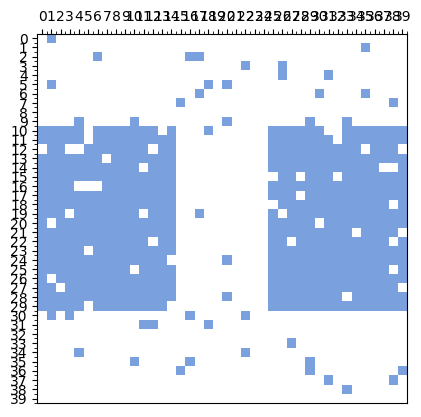

In [2]:
# comienzo la simulación montecaarlo

espesor_dispositivo = 10        # nm
Atom_size = 0.25                 # nm

eje_x = round(espesor_dispositivo / Atom_size)
eje_y = round(espesor_dispositivo / Atom_size)

num_trampas = 600

Rellenado = num_trampas/(eje_x*eje_y)

# Defino la región que quiero privilegiar y su peso
regiones_pesos = [
    ((10, eje_x-10, eje_y-15, eje_y), 50),             # First three columns with higher weight
    ((10, eje_x-10, 0, 15), 50),                       # First three columns with higher weight
]

# FIXME: Hay una zona donde nunca se ponen trampas --> Solucionado
actual_state = Generation.initial_state_priv(eje_x, eje_y, num_trampas, regiones_pesos)


RepresentateState(actual_state, 'Estado inicial')

In [3]:
total_simulation_time = 1
num_pasos = 1000
paso_temporal = total_simulation_time / num_pasos

voltaje_final = 1
paso_guardar = 1

configuraciones_matriz = np.zeros((int((num_pasos / paso_guardar)), eje_x, eje_y))

# Configuraciones iniciales:
Temperatura = 350
Campo_Electrico = 0
voltaje = 0
simulation_time = 0
Corriente = 0

# Creo el vector de datos como una matriz de num_pasos filas y 4 columnas (x,y,probabilidad recombionacion, velocidad)
num_datos = num_pasos*eje_x*eje_y
data = np.zeros((num_datos, 9))
re_index = 0

In [4]:
# Creo el excel donde voy a sacar todos los datos
for k in tqdm(range(1, num_pasos+1)):

    # Guardo el estado anterior
    last_state = actual_state

    simulation_time = paso_temporal*k

    # Calculo la corriente
    voltaje += voltaje_final * paso_temporal

    # Obtengo la corrriente, antes decido cual usar comprobando si ha percolado o no
    # TODO: Revisar por quéme dice que ha percolado si no lo ha hecho
    if Percolation.is_path(actual_state):
        # Si ha percolado uso la corriente de percolación
        # Corriente = CurentSolver.OmhCurrent(Temperatura, Campo_Electrico)
        # print("Ha percolado")
        pass
    else:
        # Si no ha percolado uso la corriente de campo
        # TODO: REVISAR QUE LA CORRIENTE TIENE LAS UNIDADES CORRECTAS PORQUE NO CUADRAN VALORES.
        Corriente = CurentSolver.poole_frenkel(Temperatura, Campo_Electrico)/(1e-10)

    # Obtengo los valores del campo eléctrico y la temperatura
    Campo_Electrico = SimpleElectricField(voltaje, espesor_dispositivo*1e-9)
    # Temperatura = Temperature_Joule(voltaje, Corriente, T_0=350)

    # Calculo la probabilidad de generación o recombinación para ello recorro toda la matriz
    for i in range(eje_x):
        for j in range(eje_y):
            if actual_state[i, j] == 0:
                # TODO: REVISAR PROBABILIDAD QUE A VECES SALE MAYOR DE 1
                # TODO: HACER UN REESCALADO DE LOS VALORES PARA EVITAR TENER QUE TRABAJAR CON NUMEROS TAN GRANDES
                prob_generacion = Generation.generation(paso_temporal, Campo_Electrico, Temperatura)
                random_number = np.random.rand()
                if random_number < prob_generacion:
                    actual_state[i, j] = 1  # Generación

            if actual_state[i, j] == 1:
                # TODO: REVISAR PROBABILIDAD QUE A VECES SALE MAYOR DE 1
                # TODO: HACER UN REESCALADO DE LOS VALORES PARA EVITAR TENER QUE TRABAJAR CON NUMEROS TAN GRANDES
                prob_recombinacion, espacio_recorr, funcion_trozos, seno_hiperbolico, beta = Recombination.recombination(
                    paso_temporal, i, Campo_Electrico, Temperatura, Atom_size)
                data[re_index] = np.array([k, simulation_time, i, j, prob_recombinacion, espacio_recorr,
                                          funcion_trozos, seno_hiperbolico, beta])
                re_index += 1
                # genero un número aleatorio entre 0 y 1
                random_number = np.random.rand()
                if random_number < prob_recombinacion:
                    actual_state[i, j] = 0  # Recombinación

    # Guardo el estado actual CADA paso_guardar PASOS MONTECARLO
    if k % paso_guardar == 0:
        configuraciones_matriz[int(k / paso_guardar) - 1] = actual_state

# Guardar la lista en un archivo
with open('Configuraciones.pkl', 'wb') as f:
    pickle.dump(configuraciones_matriz, f)

start = time.time()
np.savetxt('Recombinacion_data.csv', data,  fmt=['%d', '%.5f', '%d', '%d', '%f', '%.6e', '%.1f', '%.2e', '%f'],
           header='paso, tiempo simulacion, x, y, probabilidad recombinacion, espacio recorrido, funcion a trozos, senh, beta', comments='', delimiter=', ')
end = time.time()

print(f"Tiempo de creación del txt: {end - start:.3f} segundos")

100%|██████████| 1000/1000 [00:09<00:00, 106.00it/s]


Tiempo de creación del txt: 3.192 segundos
